# Salinity Alkalinity Curves in Deep Convection

## Package imports

In [2]:
# filter some warning messages
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import scipy
from scipy import stats
import numpy as np
import pandas as pd
import xarray as xr
from os import path
# import xesmf as xe
import scipy.signal as signal
from scipy.signal import detrend
import turtle
import dask.array as da
import intake
import cartopy.crs as ccrs
import gsw
import pickle as pkl
from datetime import datetime


os.environ['NUMPY_EXPERIMENTAL_ARRAY_FUNCTION'] = '0'
warnings.filterwarnings("ignore")
# import PyCO2SYS as pyco2


import dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client


## plotting stuff
import cartopy.crs as ccrs # for map projections
import cartopy.feature as cfeature # for map features like coastline, etc.
from cartopy.util import add_cyclic_point # get rid of the white line at 0 degree longitude for some models
import matplotlib.path as mpath
import cmocean # a nice collection of colormap

import cftime


## Pulling CMIP DATA Function

In [3]:
def get_path(model, variable, data_type, experiment_id, activity_id):
   
    import intake
    
    member_id_list = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f2", "r1i1p2f1", "r4i1p1f1","r13i1p1f2"]
    grid_list = ["gr", "gn"] 
    
    url_cimp6 = '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    cat = intake.open_esm_datastore(url_cimp6)
    cat.df.head()
    
    selected_run = None
    selected_grid = None
    
    for run in member_id_list:
        cat_subset = cat.search(
            experiment_id=[experiment_id],
            table_id= data_type,
            variable_id= variable,
            source_id=model,
            member_id=run,
            activity_id = activity_id
        )
        
        if not cat_subset.df.empty:  # If we find a valid run, store it
            selected_run = run
            
            # Now try different grid labels
            for grid in grid_list:
                #print(f"Trying grid: {grid}")  
                cat_subset = cat.search(
                    experiment_id=[experiment_id],
                    table_id= data_type,
                    variable_id= variable,
                    source_id= model,
                    member_id=selected_run,
                    activity_id = activity_id,
                    grid_label=grid
                )
    
                if not cat_subset.df.empty:  # If we find a valid grid, store it and stop
                    selected_grid = grid
                    break  # Stop searching for grids
    
            break  # Stop searching for runs once we find a valid one
    
    #print(f"Selected run: {selected_run}, Selected grid: {selected_grid}")
    path = cat_subset.df["path"].tolist()
    return path


In [32]:
def linregress_1d(x, y):
    
    from scipy.stats import linregress
    
    """
    Perform linear regression on 1D arrays.
    Returns slope, r, p-value.
    """
    ## linregress is also not very good at magically handling NaNs (this might improve at some point) ... 
    ## but in the meantime we will use numpy's .isfinite to make sure all of our inputs are finite 
    ## this will return a mask that is a boolean array that is `True` only where both x and y are valid numbers.
    mask = np.isfinite(x) & np.isfinite(y) 

    # linregress requires at least 3 points to work, so this is a safety check in case there is a place with less data points than that 
    #we are using model data right now so this is not strictly necessary, but if you work with real data in the future data it may be important 
    if mask.sum() < 3: # counts how many 'True' in mask (aka how many real values) 
        # just says that if we don't have enought points to run a linear regression
        #then we will put a Nan as the result in our slope, correlation, and p-valu fields (the return of the function) 
        return np.nan, np.nan, np.nan 

    ## Take linear regression when arrays are valid 
    ### applies the mask to x and y, this will drop all NaNs from the arrays, leaving only valid datapoints
    ## we save the results of the linear regression to a variable called "res" 
    ## we can call values from our results later using ."attribute" 
    res = linregress(x[mask], y[mask]) 

    # this function returns the 3 values we are looking for here (slope, r,value, pvalue), by calling them from the results 
    return res.slope, res.rvalue, res.pvalue, res.intercept


## Specify Models & variables

In [5]:
model = "GFDL-CM4"
variable = "fgco2"

## Create Convection Masks

Deep Convection will be defined as areas where the mixed layer depth (MLD) reached a depth greater than 2000 meters in the month of september (SO winter). Right now I will use the models saved version of MLD. 

**Pull MLD Data**

In [6]:
#get the path to the MLD data for the choosen model 
#function form take arguments: model, variable, data_type, experiment_id, activity_id - see above
    #here I am using the model GFDL-CM4, pulling MLD data, in the Ocean Monthly (Omon) format, for the //
    #pre-industrial control experiment in the CMIP file 

path_mld = get_path(model,"mlotst", "Omon", "piControl","CMIP")
#print(path_mld)

In [7]:
MODEL_MLD = xr.open_mfdataset(path_mld, chunks = None) # open mld data into a xarray dataset (opens all files as one dataset) 
MODEL_MLD_SO = MODEL_MLD.sel(lat=slice(-90, -40)) #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_MLD_SO_sept = MODEL_MLD_SO.sel(time=MODEL_MLD_SO['time'].dt.month == 9) # pull the september month data (results in 500 point time dimension - 1 month for 500 yrs) 

#display dataset to see vars and dimesions 
MODEL_MLD_SO_sept 

<xarray.Dataset> Size: 39MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d9acf7e3-3970-44c5-bb0d-57ec2bc0c5ad
    variable_id:            mlotst
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

**Deep Convection Area Mask**

For every year in the 500 year time period, check if the MLD is greater than or equal to 2000 m. If it is then write a value of 1, if it is not, write a value of zero. Results in a mask with dimensions of lat, lon, time 

In [8]:
#1 where the mixed-layer depth (MLD) is ≥ 2000 (“deep convection” criterion), and 0 everywhere else
convection_area_mask = xr.where(MODEL_MLD_SO_sept>=2000, 1, 0)  # this is the mask of deep convection (x, y, t)

#display mask to check dimensions and vars
convection_area_mask

<xarray.Dataset> Size: 75MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) int64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) int64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) int64 72MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) int64 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>

In [9]:
## ross sea deep convection mask (bottom blob) 
deep_area_mask_ross = convection_area_mask.where(
    (convection_area_mask.lon >= 150) & (convection_area_mask.lon <= 240),
    other=0)

In [10]:
## wedell deep convection mask (top blob) 
deep_area_mask_weddell = convection_area_mask.where(
    (convection_area_mask.lon >= 300) | (convection_area_mask.lon <= 30),
    other=0)

**Not Convection Area Mask**

The reverse of the convection area mask, gives a 1 where MLD is less than 2000, everywhere else is 0 

In [11]:
NOTconvection_area_mask = xr.where(MODEL_MLD_SO_sept < 2000, 1, 0)  # this is the mask of deep convection (x, y, t)
#1 where the mixed-layer depth (MLD) is < 2000 (“deep convection” criterion), and 0 everywhere else

#display mask to check dimensions and vars
NOTconvection_area_mask

<xarray.Dataset> Size: 75MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) int64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) int64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    mlotst     (time, lat, lon) int64 72MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) int64 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>

In [12]:
## ross sea Not deep convection mask (bottom blob) 
NOTconvection_area_mask_ross = NOTconvection_area_mask.where(
    (NOTconvection_area_mask.lon >= 150) & (NOTconvection_area_mask.lon <= 240),
    other=0)

In [13]:
## wedell Not deep convection mask (top blob) 
NOTconvection_area_mask_weddell = NOTconvection_area_mask.where(
    (NOTconvection_area_mask.lon >= 300) | (NOTconvection_area_mask.lon <= 30),
    other=0)

**Total Convection Area Mask**

This mask gives the total area than has deep convection in any of the 500 years, sort of the total area that has potential for deep convection. Gives a 1 for the area that is deep convection  

In [14]:
convection_total_mask = xr.where(convection_area_mask.mean("time") > 0, 1, 0)   # this is the mask of total convection area (x, y)
# gives a one whereever deep convection has occured in any of the 500 years

#display mask to check dimensions and vars
convection_total_mask

<xarray.Dataset> Size: 154kB
Dimensions:    (lat: 50, bnds: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) int64 800B dask.array<chunksize=(50, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) int64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    mlotst     (lat, lon) int64 144kB dask.array<chunksize=(50, 360), meta=np.ndarray>
    time_bnds  (bnds) int64 16B dask.array<chunksize=(2,), meta=np.ndarray>

In [15]:
## ross sea total convection mask (bottom blob) 
convection_total_mask_ross = convection_total_mask.where(
    (convection_total_mask.lon >= 150) & (convection_total_mask.lon <= 240),
    other=0)

In [16]:
## wedell total convection mask (top blob) 
convection_total_mask_weddell = NOTconvection_area_mask.where(
    (convection_total_mask.lon >= 300) | (convection_total_mask.lon <= 30),
    other=0)

## Salinity and Alk Data

**salinity** 

In [17]:
#get the path to the salinity data for the chosen model 
#function form take arguments: model, variable, data_type, experiment_id, activity_id - see above
    #here I am using the model GFDL-CM4, pulling po4 data, in the Ocean Monthly (Omon) format, for the //
    #pre-industrial control experiment in the CMIP file 
    #note pulling po4 for GFDL-CM4 b/c it does not have a no3 feild 

path_sos = get_path(model ,'sos', "Omon", "piControl","CMIP")
#print(path)

In [18]:
MODEL_SOS = xr.open_mfdataset(path_sos, chunks = None)  # open po4 data into a xarray dataset (opens all files as one dataset) 
MODEL_SOS_SO = MODEL_SOS.sel(lat=slice(-90, -40))  #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_SOS_SO_sept = MODEL_SOS_SO.sel(time=MODEL_SOS_SO['time'].dt.month == 9) # pull the November month data (results in 500 point time dimension - 1 month for 500 yrs)

## --- remap November dates to September, using cftime.DatetimeNoLeap ---
#new_time = [
    #cftime.DatetimeNoLeap(t.dt.year.item(), 9, 16, 0, 0, 0, 0, has_year_zero=True)
    #for t in MODEL_VAR_SO_nov['time']
#]
#MODEL_VAR_SO_nov = MODEL_VAR_SO_nov.assign_coords(time=("time", new_time))

# pull only surface levels of nutrient for now 
if 'lev' in MODEL_SOS_SO_sept.coords:
    MODEL_SOS_SO_sept_surface = MODEL_SOS_SO_sept.isel(lev=0)
else: 
    MODEL_SOS_SO_sept_surface = MODEL_SOS_SO_sept

MODEL_SOS_SO_sept_surface

<xarray.Dataset> Size: 39MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    sos        (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/6b17908c-5597-4a20-8fa8-cdbb8b73b054
    variable_id:            sos
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

**alkalinity** 

In [19]:
#get the path to the salinity data for the chosen model 
#function form take arguments: model, variable, data_type, experiment_id, activity_id - see above
    #here I am using the model GFDL-CM4, pulling po4 data, in the Ocean Monthly (Omon) format, for the //
    #pre-industrial control experiment in the CMIP file 
    #note pulling po4 for GFDL-CM4 b/c it does not have a no3 feild 

path_talk= get_path(model ,'talk', "Omon", "piControl","CMIP")
#print(path)

In [20]:
MODEL_TALK = xr.open_mfdataset(path_talk, chunks = None)  # open po4 data into a xarray dataset (opens all files as one dataset) 
MODEL_TALK_SO = MODEL_TALK.sel(lat=slice(-90, -40))  #pull only southern ocean latitudes (avoid uneccecary computation) 
MODEL_TALK_SO_sept = MODEL_TALK_SO.sel(time=MODEL_TALK_SO['time'].dt.month == 9) # pull the November month data (results in 500 point time dimension - 1 month for 500 yrs)

## --- remap November dates to September, using cftime.DatetimeNoLeap ---
#new_time = [
    #cftime.DatetimeNoLeap(t.dt.year.item(), 9, 16, 0, 0, 0, 0, has_year_zero=True)
    #for t in MODEL_VAR_SO_nov['time']
#]
#MODEL_VAR_SO_nov = MODEL_VAR_SO_nov.assign_coords(time=("time", new_time))

# pull only surface levels of nutrient for now 
if 'lev' in MODEL_TALK_SO_sept.coords:
    MODEL_TALK_SO_sept_surface = MODEL_TALK_SO_sept.isel(lev=0)
else: 
    MODEL_TALK_SO_sept_surface = MODEL_TALK_SO_sept

MODEL_TALK_SO_sept_surface

<xarray.Dataset> Size: 39MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lev        float64 8B 2.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds) float64 400kB dask.array<chunksize=(240, 50, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(240, 360, 2), meta=np.ndarray>
    talk       (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 180), meta=np.ndarray>
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lev_bnds   (time, bnds) float64 8kB dask.array<chunksize=(240, 2), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello volcello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/c38fe367-dafd-4dbe-86dc-e36d897fbdf9
    variable_id:            talk
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

## Deep Convection Areas

**salinity**

In [21]:
##Convection masked areas 
# ensure mask is boolean, same dims
mask_deepConvection = (convection_area_mask == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned, SOS_aligned = xr.align(mask_deepConvection, MODEL_SOS_SO_sept_surface)

SOS_deepconvection = SOS_aligned.where(mask_deepConvection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
SOS_deepconvection

<xarray.Dataset> Size: 468MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    sos        (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/6b17908c-5597-4a20-8fa8-cdbb8b73b054
    variable_id:            sos
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [22]:
##Convection masked areas -ross
# ensure mask is boolean, same dims
mask_deepConvection_ross = (deep_area_mask_ross  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned_ross, SOS_aligned_ross = xr.align(mask_deepConvection_ross, MODEL_SOS_SO_sept_surface)

SOS_deepconvection_ROSS = SOS_aligned_ross.where(mask_deepConvection_aligned_ross['mlotst']) #mask is saved in the mld feild of the dataset 

##Convection masked areas - weddelle
# ensure mask is boolean, same dims
mask_deepConvection_weddell= (deep_area_mask_weddell  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned_weddell, SOS_aligned_weddell = xr.align(mask_deepConvection_weddell, MODEL_SOS_SO_sept_surface)

SOS_deepconvection_WEDDELL = SOS_aligned_weddell.where(mask_deepConvection_aligned_weddell['mlotst']) #mask is saved in the mld feild of the dataset 


**alkalinity**

In [23]:
##Convection masked areas 
# ensure mask is boolean, same dims
mask_deepConvection = (convection_area_mask == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned, TALK_aligned = xr.align(mask_deepConvection, MODEL_TALK_SO_sept_surface)

TALK_deepconvection = TALK_aligned.where(mask_deepConvection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
TALK_deepconvection

<xarray.Dataset> Size: 612MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lev        float64 8B 2.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    talk       (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 180), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
    lev_bnds   (time, bnds, lat, lon) float64 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello volcello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/c38fe367-dafd-4dbe-86dc-e36d897fbdf9
    variable_id:            talk
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [24]:
##Convection masked areas -ross
# ensure mask is boolean, same dims
mask_deepConvection_ross = (deep_area_mask_ross  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned_ross, TALK_aligned_ross = xr.align(mask_deepConvection_ross, MODEL_TALK_SO_sept_surface)

TALK_deepconvection_ROSS = TALK_aligned_ross.where(mask_deepConvection_aligned_ross['mlotst']) #mask is saved in the mld feild of the dataset 

##Convection masked areas - weddelle
# ensure mask is boolean, same dims
mask_deepConvection_weddell= (deep_area_mask_weddell  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned_weddell, TALK_aligned_weddell = xr.align(mask_deepConvection_weddell, MODEL_TALK_SO_sept_surface)

TALK_deepconvection_WEDDELL = TALK_aligned_weddell.where(mask_deepConvection_aligned_weddell['mlotst']) #mask is saved in the mld feild of the dataset 


**mixed layer depth**

In [25]:

##Convection masked areas 
# ensure mask is boolean, same dims
mask_deepConvection = (convection_area_mask == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned, MLD_aligned = xr.align(mask_deepConvection, MODEL_MLD_SO_sept)

MLD_deepconvection = MLD_aligned.where(mask_deepConvection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
MLD_deepconvection

<xarray.Dataset> Size: 468MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    mlotst     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d9acf7e3-3970-44c5-bb0d-57ec2bc0c5ad
    variable_id:            mlotst
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [26]:
##Convection masked areas -ross
# ensure mask is boolean, same dims
mask_deepConvection_ross = (deep_area_mask_ross  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned_ross, MLD_aligned_ross = xr.align(mask_deepConvection_ross, MODEL_MLD_SO_sept)

MLD_deepconvection_ROSS = MLD_aligned_ross.where(mask_deepConvection_aligned_ross['mlotst']) #mask is saved in the mld feild of the dataset 

##Convection masked areas - weddelle
# ensure mask is boolean, same dims
mask_deepConvection_weddell= (deep_area_mask_weddell  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_deepConvection_aligned_weddell, MLD_aligned_weddell = xr.align(mask_deepConvection_weddell, MODEL_MLD_SO_sept)

MLD_deepconvection_WEDDELL = MLD_aligned_weddell.where(mask_deepConvection_aligned_weddell['mlotst']) #mask is saved in the mld feild of the dataset 


In [28]:
deep_salinity_vals = SOS_deepconvection['sos'].values.flatten()
deep_alkalinity_vals = TALK_deepconvection['talk'].values.flatten()
deep_mld_vals = MLD_deepconvection['mlotst'].values.flatten()

deep_salinity_ross = SOS_deepconvection_ROSS['sos'].values.flatten()
deep_alkalinity_ross = TALK_deepconvection_ROSS['talk'].values.flatten()
deep_mld_ross = MLD_deepconvection_ROSS['mlotst'].values.flatten()

deep_salinity_weddell = SOS_deepconvection_WEDDELL['sos'].values.flatten()
deep_alkalinity_weddell =  TALK_deepconvection_WEDDELL['talk'].values.flatten()
deep_mld_weddell = MLD_deepconvection_WEDDELL['mlotst'].values.flatten()

# Keep only points where BOTH salinity and alkalinity are valid - all
valid_mask_all = ~np.isnan(deep_salinity_vals) & ~np.isnan(deep_alkalinity_vals) & ~np.isnan(deep_mld_vals)
deep_salinity_vals = deep_salinity_vals[valid_mask_all]
deep_alkalinity_vals = deep_alkalinity_vals[valid_mask_all]
deep_mld_vals = deep_mld_vals[valid_mask_all] 

# Keep only points where BOTH salinity and alkalinity are valid - ross
valid_mask_ross = ~np.isnan(deep_salinity_ross) & ~np.isnan(deep_alkalinity_ross) & ~np.isnan(deep_mld_ross)
deep_salinity_ross = deep_salinity_ross[valid_mask_ross]
deep_alkalinity_ross = deep_alkalinity_ross[valid_mask_ross]
deep_mld_ross = deep_mld_ross[valid_mask_ross] 

# Keep only points where BOTH salinity and alkalinity are valid - weddelle
valid_mask_weddell = ~np.isnan(deep_salinity_weddell) & ~np.isnan(deep_alkalinity_weddell) & ~np.isnan(deep_mld_weddell)
deep_salinity_weddell = deep_salinity_weddell[valid_mask_weddell]
deep_alkalinity_weddell = deep_alkalinity_weddell[valid_mask_weddell]
deep_mld_weddell = deep_mld_weddell[valid_mask_weddell] 

#  check
print(f"Points after filtering: {valid_mask_all.sum()}")
print(f"Salinity NaNs remaining:   {np.isnan(deep_salinity_vals).sum()}")
print(f"Alkalinity NaNs remaining: {np.isnan(deep_alkalinity_vals).sum()}")
assert len(deep_salinity_vals) == len(deep_alkalinity_vals), "Arrays are not the same length!"

Points after filtering: 2062
Salinity NaNs remaining:   0
Alkalinity NaNs remaining: 0


In [33]:
deep_regression_ross = linregress_1d(deep_salinity_ross, deep_alkalinity_ross)
deep_regression_weddell = linregress_1d(deep_salinity_weddell, deep_alkalinity_weddell)

deep_slope_ross = deep_regression_ross [0]
deep_slope_weddell = deep_regression_weddell[0]

deep_r_ross = deep_regression_ross[1]
deep_r_weddell = deep_regression_weddell[1]

deep_p_ross = deep_regression_ross[2]
deep_p_weddell = deep_regression_weddell[2]

deep_b_ross = deep_regression_ross[3]
deep_b_weddell = deep_regression_weddell[3]

print(deep_slope_ross,deep_slope_weddell)
print(deep_r_ross,deep_r_weddell)
print(deep_p_ross,deep_p_weddell)
print(deep_b_ross,deep_b_weddell)

0.07661180582468025 0.07570675719379455
0.9522084706379932 0.6868899949918529
0.0 1.4872665197329086e-123
-0.22184279826378805 -0.1873235788806933


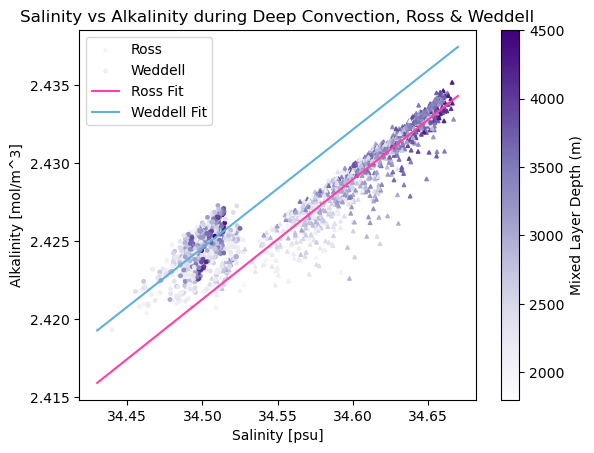

In [34]:
vmin = 1800
vmax = 4500
xvals = np.linspace(34.43,34.67,1000) 

linfit_deep_ross = deep_slope_ross * xvals + deep_b_ross
linfit_deep_weddell = deep_slope_weddell * xvals + deep_b_weddell
plt.scatter(deep_salinity_ross,deep_alkalinity_ross,c=deep_mld_ross,  s = 6, marker="^", 
            cmap='Purples',vmin=vmin, vmax=vmax, label = "Ross") 
plt.scatter(deep_salinity_weddell,deep_alkalinity_weddell,c=deep_mld_weddell,  s = 6, marker="o" ,
            cmap='Purples',vmin=vmin, vmax=vmax, label = "Weddell") 
cbar = plt.colorbar() # Adds a legend for the colors
cbar.set_label("Mixed Layer Depth (m)")

plt.plot(xvals, linfit_deep_ross, c='#ff40a6', label = "Ross Fit") 
plt.plot(xvals, linfit_deep_weddell, c = '#60b0db', label = "Weddell Fit") 
plt.title("Salinity vs Alkalinity during Deep Convection, Ross & Weddell") 
plt.xlabel("Salinity [psu]") 
plt.ylabel("Alkalinity [mol/m^3]")
plt.legend()

 Buffering Capacity: In a local context, a steeper slope suggests that as salinity increases, the alkalinity-based buffering capacity of the water increases

## Total Deep Convection Areas 

**Salinty**

In [35]:
## Non-deep Convection masked areas 
# ensure mask is boolean, same dims
mask_total_Convection = (convection_total_mask== 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_total_Convection_aligned, SOS_aligned = xr.align(mask_total_Convection, MODEL_SOS_SO_sept_surface)

SOS_totalconvection = SOS_aligned.where(mask_total_Convection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
SOS_totalconvection

<xarray.Dataset> Size: 468MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(240, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(240, 360, 2, 50), meta=np.ndarray>
    sos        (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/6b17908c-5597-4a20-8fa8-cdbb8b73b054
    variable_id:            sos
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [36]:
##Convection masked areas -ross
# ensure mask is boolean, same dims
mask_total_Convection_ross = (convection_total_mask_ross  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned_ross, SOS_aligned_ross = xr.align(mask_total_Convection_ross, MODEL_SOS_SO_sept_surface)

SOS_totalconvection_ROSS = SOS_aligned_ross.where(mask_totalConvection_aligned_ross['mlotst']) #mask is saved in the mld feild of the dataset 

##Convection masked areas - weddelle
# ensure mask is boolean, same dims
mask_total_Convection_weddell= (convection_total_mask_weddell  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned_weddell, SOS_aligned_weddell = xr.align(mask_total_Convection_weddell, MODEL_SOS_SO_sept_surface)

SOS_totalconvection_WEDDELL = SOS_aligned_weddell.where(mask_totalConvection_aligned_weddell['mlotst']) #mask is saved in the mld feild of the dataset 


**alkalinity**

In [37]:
##Non deep Convection masked areas 
# ensure mask is boolean, same dims
mask_total_Convection = (convection_total_mask== 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_total_Convection_aligned, TALK_aligned = xr.align(mask_total_Convection, MODEL_TALK_SO_sept_surface)

TALK_totalconvection = TALK_aligned.where(mask_total_Convection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
TALK_totalconvection

<xarray.Dataset> Size: 612MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lev        float64 8B 2.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(240, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(240, 360, 2, 50), meta=np.ndarray>
    talk       (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 180), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
    lev_bnds   (time, bnds, lat, lon) float64 144MB dask.array<chunksize=(240, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello volcello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/c38fe367-dafd-4dbe-86dc-e36d897fbdf9
    variable_id:            talk
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [38]:
##Convection masked areas -ross
# ensure mask is boolean, same dims
mask_total_Convection_ross = (convection_total_mask_ross  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned_ross, TALK_aligned_ross = xr.align(mask_total_Convection_ross, MODEL_TALK_SO_sept_surface)

TALK_totalconvection_ROSS = TALK_aligned_ross.where(mask_totalConvection_aligned_ross['mlotst']) #mask is saved in the mld feild of the dataset 

##Convection masked areas - weddelle
# ensure mask is boolean, same dims
mask_total_Convection_weddell= (convection_total_mask_weddell  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned_weddell, TALK_aligned_weddell = xr.align(mask_total_Convection_weddell, MODEL_TALK_SO_sept_surface)

TALK_totalconvection_WEDDELL = TALK_aligned_weddell.where(mask_totalConvection_aligned_weddell['mlotst']) #mask is saved in the mld feild of the dataset 


**MLD**

In [39]:

##Convection masked areas 
# ensure mask is boolean, same dims
mask_total_Convection = (convection_total_mask == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned, MLD_aligned = xr.align(mask_total_Convection, MODEL_MLD_SO_sept)

MLD_totalconvection = MLD_aligned.where(mask_deepConvection_aligned['mlotst']) #mask is saved in the mld feild of the dataset 

# ensure correct variables and dimensions preserved 
MLD_totalconvection

<xarray.Dataset> Size: 468MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    mlotst     (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/d9acf7e3-3970-44c5-bb0d-57ec2bc0c5ad
    variable_id:            mlotst
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [40]:
##Convection masked areas -ross
# ensure mask is boolean, same dims
mask_total_Convection_ross = (convection_total_mask_ross  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned_ross, MLD_aligned_ross = xr.align(mask_total_Convection_ross, MODEL_MLD_SO_sept)

MLD_totalconvection_ROSS = MLD_aligned_ross.where(mask_totalConvection_aligned_ross['mlotst']) #mask is saved in the mld feild of the dataset 

##Convection masked areas - weddelle
# ensure mask is boolean, same dims
mask_total_Convection_weddell= (convection_total_mask_weddell  == 1)

# align mask to sos before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#used sept, surface po4 data for SO 
mask_totalConvection_aligned_weddell, MLD_aligned_weddell = xr.align(mask_total_Convection_weddell, MODEL_MLD_SO_sept)

MLD_totalconvection_WEDDELL = MLD_aligned_weddell.where(mask_totalConvection_aligned_weddell['mlotst']) #mask is saved in the mld feild of the dataset 


In [42]:
total_salinity_vals = SOS_totalconvection['sos'].values.flatten()
total_alkalinity_vals = TALK_totalconvection['talk'].values.flatten()
total_mld_vals = MLD_totalconvection['mlotst'].values.flatten()

total_salinity_ross = SOS_totalconvection_ROSS['sos'].values.flatten()
total_alkalinity_ross = TALK_totalconvection_ROSS['talk'].values.flatten()
total_mld_ross = MLD_totalconvection_ROSS['mlotst'].values.flatten()

total_salinity_weddell = SOS_totalconvection_WEDDELL['sos'].values.flatten()
total_alkalinity_weddell =  TALK_totalconvection_WEDDELL['talk'].values.flatten()
total_mld_weddell = MLD_totalconvection_WEDDELL['mlotst'].values.flatten()

# Keep only points where BOTH salinity and alkalinity are valid - all
valid_mask_all = ~np.isnan(total_salinity_vals) & ~np.isnan(total_alkalinity_vals) & ~np.isnan(total_mld_vals)
total_salinity_vals = total_salinity_vals[valid_mask_all]
total_alkalinity_vals = total_alkalinity_vals[valid_mask_all]
total_mld_vals = total_mld_vals[valid_mask_all] 

# Keep only points where BOTH salinity and alkalinity are valid - ross
valid_mask_ross = ~np.isnan(total_salinity_ross) & ~np.isnan(total_alkalinity_ross) & ~np.isnan(total_mld_ross)
total_salinity_ross = total_salinity_ross[valid_mask_ross]
total_alkalinity_ross = total_alkalinity_ross[valid_mask_ross]
total_mld_ross = total_mld_ross[valid_mask_ross] 

# Keep only points where BOTH salinity and alkalinity are valid - weddelle
valid_mask_weddell = ~np.isnan(total_salinity_weddell) & ~np.isnan(total_alkalinity_weddell) & ~np.isnan(total_mld_weddell)
total_salinity_weddell = total_salinity_weddell[valid_mask_weddell]
total_alkalinity_weddell = total_alkalinity_weddell[valid_mask_weddell]
total_mld_weddell = total_mld_weddell[valid_mask_weddell] 

#  check
print(f"Points after filtering: {valid_mask_all.sum()}")
print(f"Salinity NaNs remaining:   {np.isnan(total_salinity_vals).sum()}")
print(f"Alkalinity NaNs remaining: {np.isnan(total_alkalinity_vals).sum()}")
assert len(total_salinity_vals) == len(total_alkalinity_vals), "Arrays are not the same length!"

Points after filtering: 2062
Salinity NaNs remaining:   0
Alkalinity NaNs remaining: 0


In [50]:
total_regression_ross = linregress_1d(total_salinity_ross, total_alkalinity_ross)
total_regression_weddell = linregress_1d(total_salinity_weddell, total_alkalinity_weddell)

total_slope_ross = total_regression_ross [0]
total_slope_weddell = total_regression_weddell[0]

total_r_ross = total_regression_ross[1]
total_r_weddell = total_regression_weddell[1]

total_p_ross = total_regression_ross[2]
total_p_weddell = total_regression_weddell[2]

total_b_ross = total_regression_ross[3]
total_b_weddell = total_regression_weddell[3]

print(total_slope_ross,total_slope_weddell)
print(total_r_ross,total_r_weddell)
print(total_p_ross,total_p_weddell)
print(total_b_ross,total_b_weddell)

0.093392200372559 0.059214079790728534
0.9786528817555784 0.7837107075180184
0.0 0.0
-0.8048624067039487 0.3641902099369485


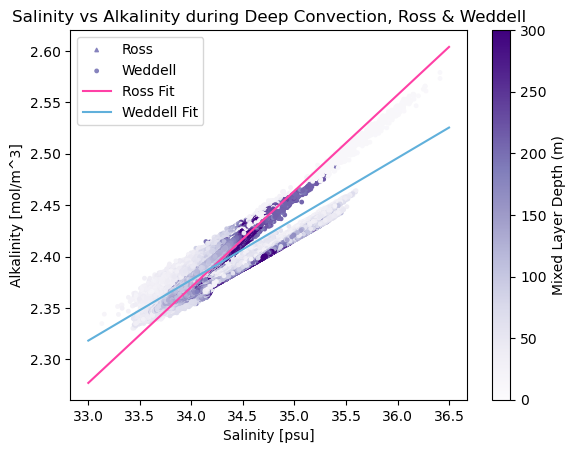

In [ ]:
vmin = 0
vmax = 300
xvals = np.linspace(33.0,36.0,1000) 

linfit_total_ross = total_slope_ross * xvals + total_b_ross
linfit_total_weddell = total_slope_weddell * xvals + total_b_weddell
plt.scatter(total_salinity_ross,total_alkalinity_ross,c=total_mld_ross,  s = 6, marker="^", 
            cmap='Purples',vmin=vmin, vmax=vmax, label = "Ross") 
plt.scatter(total_salinity_weddell,total_alkalinity_weddell,c=total_mld_weddell,  s = 6, marker="o" ,
            cmap='Purples',vmin=vmin, vmax=vmax, label = "Weddell") 
cbar = plt.colorbar() # Adds a legend for the colors
cbar.set_label("Mixed Layer Depth (m)")

plt.plot(xvals, linfit_total_ross, c='#ff40a6', label = "Ross Fit") 
plt.plot(xvals, linfit_total_weddell, c = '#60b0db', label = "Weddell Fit") 
plt.title("Salinity vs Alkalinity during Deep Convection, Ross & Weddell") 
plt.xlabel("Salinity [psu]") 
plt.ylabel("Alkalinity [mol/m^3]")
plt.legend()

## Not deep convective in total convective area 

This takes the nutrient that is in the total convective area (feild above) (500 time steps, only data in the total convective areas (nans elsewhere)), and then masks it with the Not deep convection mask (500 yrs, lat below -40, all log), effectively removing all the data points here that are considered deep convection in the convective area 

**Salinity**

In [ ]:
##Non deep Convection masked areas 
# ensure mask is boolean, same dims
mask_NOTdeepConvection = (NOTconvection_area_mask == 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#uses the PO4 data, filtered in the total convective area from above
mask_NOTdeepConvection_aligned, SOS_aligned = xr.align(mask_NOTdeepConvection, SOS_total_convection)

SOS_NOTdeepconvection_ConvArea = SOS_aligned.where(mask_NOTdeepConvection_aligned['mlotst'])

# ensure correct variables and dimensions preserved 
SOS_NOTdeepconvection_ConvArea 

<xarray.Dataset> Size: 468MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    sos        (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 360), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/6b17908c-5597-4a20-8fa8-cdbb8b73b054
    variable_id:            sos
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

**alkalinity**

In [ ]:
##Non deep Convection masked areas 
# ensure mask is boolean, same dims
mask_NOTdeepConvection = (NOTconvection_area_mask == 1)

# align mask to PO4 before applying -> make sure all dimensions are the same
#fills any missing dimensions with nans, aligns dimensions 
#uses the PO4 data, filtered in the total convective area from above
mask_NOTdeepConvection_aligned, TALK_aligned = xr.align(mask_NOTdeepConvection, TALK_total_convection)

TALK_NOTdeepconvection_ConvArea = TALK_aligned.where(mask_NOTdeepConvection_aligned['mlotst'])

# ensure correct variables and dimensions preserved 
TALK_NOTdeepconvection_ConvArea 

<xarray.Dataset> Size: 612MB
Dimensions:    (time: 500, lat: 50, bnds: 2, lon: 360)
Coordinates:
  * time       (time) object 4kB 0151-09-16 00:00:00 ... 0650-09-16 00:00:00
  * lat        (lat) float64 400B -89.5 -88.5 -87.5 -86.5 ... -42.5 -41.5 -40.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lev        float64 8B 2.5
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, lat, bnds, lon) float64 144MB dask.array<chunksize=(1, 50, 2, 360), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, lat) float64 144MB dask.array<chunksize=(1, 360, 2, 50), meta=np.ndarray>
    talk       (time, lat, lon) float32 36MB dask.array<chunksize=(1, 50, 180), meta=np.ndarray>
    time_bnds  (time, bnds, lat, lon) object 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
    lev_bnds   (time, bnds, lat, lon) float64 144MB dask.array<chunksize=(1, 2, 50, 360), meta=np.ndarray>
Attributes: (12/46)
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    history:                File was processed by fremetar (GFDL analog of CM...
    external_variables:     areacello volcello
    table_id:               Omon
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    sub_experiment_id:      none
    tracking_id:            hdl:21.14100/c38fe367-dafd-4dbe-86dc-e36d897fbdf9
    variable_id:            talk
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [ ]:
notdeep_salinity_vals = SOS_NOTdeepconvection_ConvArea['sos'].values.flatten()
notdeep_alkalinity_vals = TALK_NOTdeepconvection_ConvArea['talk'].values.flatten()

# Keep only points where BOTH salinity and alkalinity are valid
valid_mask = ~np.isnan(notdeep_salinity_vals) & ~np.isnan(notdeep_alkalinity_vals)
notdeep_salinity_vals = notdeep_salinity_vals[valid_mask]
notdeep_alkalinity_vals = notdeep_alkalinity_vals[valid_mask]

#  check
print(f"Points after filtering: {valid_mask.sum()}")
print(f"Salinity NaNs remaining:   {np.isnan(notdeep_salinity_vals).sum()}")
print(f"Alkalinity NaNs remaining: {np.isnan(notdeep_alkalinity_vals).sum()}")
assert len(notdeep_salinity_vals) == len(notdeep_alkalinity_vals), "Arrays are not the same length!"

Points after filtering: 275438
Salinity NaNs remaining:   0
Alkalinity NaNs remaining: 0


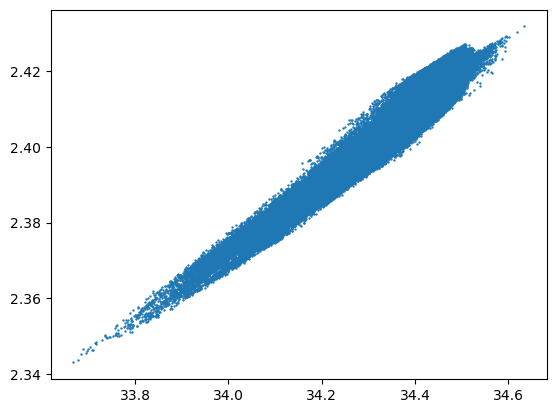

In [ ]:
plt.scatter(notdeep_salinity_vals,notdeep_alkalinity_vals, s = .5) 

## Alkalinity vs Salinity Charts 

In [ ]:
import scipy.stats as st 
from scipy.stats import linregress #this is the new package we will be using to do our correlations 


In [ ]:
def linregress_1d(x, y):
    
    """
    Perform linear regression on 1D arrays.
    Returns slope, r, p-value.
    """
    ## linregress is also not very good at magically handling NaNs (this might improve at some point) ... 
    ## but in the meantime we will use numpy's .isfinite to make sure all of our inputs are finite 
    ## this will return a mask that is a boolean array that is `True` only where both x and y are valid numbers.
    mask = np.isfinite(x) & np.isfinite(y) 

    # linregress requires at least 3 points to work, so this is a safety check in case there is a place with less data points than that 
    #we are using model data right now so this is not strictly necessary, but if you work with real data in the future data it may be important 
    if mask.sum() < 3: # counts how many 'True' in mask (aka how many real values) 
        # just says that if we don't have enought points to run a linear regression
        #then we will put a Nan as the result in our slope, correlation, and p-valu fields (the return of the function) 
        return np.nan, np.nan, np.nan 

    ## Take linear regression when arrays are valid 
    ### applies the mask to x and y, this will drop all NaNs from the arrays, leaving only valid datapoints
    ## we save the results of the linear regression to a variable called "res" 
    ## we can call values from our results later using ."attribute" 
    res = linregress(x[mask], y[mask]) 

    # this function returns the 3 values we are looking for here (slope, r,value, pvalue), by calling them from the results 
    return res.slope, res.rvalue, res.pvalue, res.intercept


In [ ]:
deep_regression = linregress_1d(deep_salinity_vals, deep_alkalinity_vals)
notdeep_regression = linregress_1d(notdeep_salinity_vals, notdeep_alkalinity_vals)
total_regression = linregress_1d(total_salinity_vals, total_alkalinity_vals)

deep_slope = deep_regression[0]
notdeep_slope = notdeep_regression[0]
total_slope = total_regression[0]

deep_r = deep_regression[1]
notdeep_r = notdeep_regression[1]
total_r = total_regression[1]

deep_p = deep_regression[2]
notdeep_p = notdeep_regression[2]
total_p = total_regression[2]

deep_b = deep_regression[3]
notdeep_b = notdeep_regression[3]
total_b = total_regression[3]

print(deep_slope,notdeep_slope,total_slope)
print(deep_r,notdeep_r,total_r)
print(deep_p,notdeep_p,total_p)
print(deep_b,notdeep_b,total_b)

0.05369859208403363 0.10738805339312392 0.1071974992756041
0.9295007074949071 0.9623362502890531 0.9626404533684889
0.0 0.0 0.0
0.571460678924093 -1.283405065539264 -1.2768569774719203


In [ ]:
x_vals_deep = np.linspace(33.6,34.7,100)
x_vals_total = np.linspace(33.6,34.7,100)
x_vals_notdeep = np.linspace(33.6,34.7,100)

y_linfit_deep = deep_slope *x_vals_deep + deep_b 
y_linfit_total = total_slope * x_vals_total + notdeep_b
y_linfit_notdeep = notdeep_slope * x_vals_notdeep + total_b

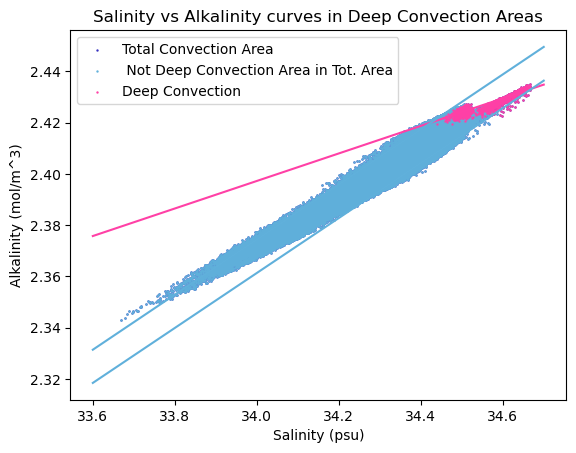

In [ ]:
plt.scatter(total_salinity_vals,total_alkalinity_vals, s = .5, c = '#332ebf' , label ="Total Convection Area") 
plt.scatter(notdeep_salinity_vals,notdeep_alkalinity_vals, s = .5, c = '#60b0db',label =" Not Deep Convection Area in Tot. Area") 
plt.scatter(deep_salinity_vals,deep_alkalinity_vals, s = .5, c='#ff40a6', label ="Deep Convection") 

plt.plot(x_vals_deep, y_linfit_deep, c='#ff40a6') 
plt.plot(x_vals_total, y_linfit_total, c = '#60b0db') 
plt.plot(x_vals_notdeep ,y_linfit_notdeep, c = '#60b0db') 

plt.xlabel("Salinity (psu)") 
plt.ylabel("Alkalinity (mol/m^3)")
plt.title("Salinity vs Alkalinity curves in Deep Convection Areas") 
plt.legend()